<a href="https://colab.research.google.com/github/Valrite/Digital-Image-Processing-Labs/blob/main/Lab6/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

im = cv2.imread("images/test.png",0)

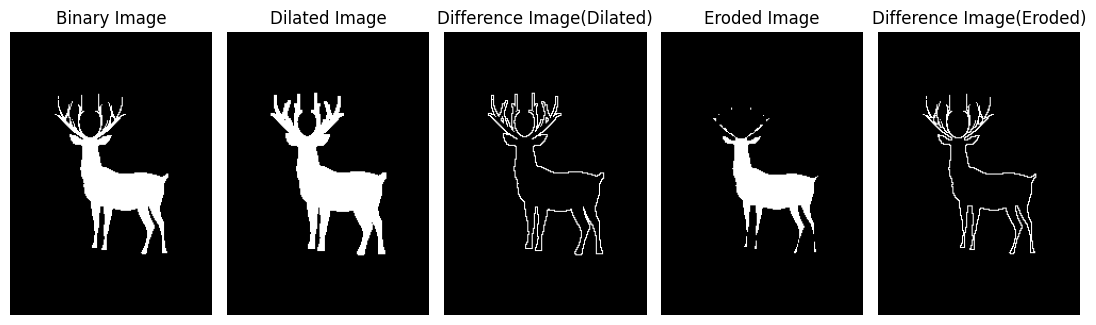

In [ ]:
""" Write a Program to read an image, first apply erosion to the image and
    then subtract the result from the original.
    Apply dilation to the image and then subtract it with the original.
    Observe and demonstrate the differences in each
"""

#import the necessary libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np

# define a function to perform the morphological operations
def binary_morph(img, kernel, iterations=1, mode='dilate'):
    ksize=kernel.shape[0]
    pad= ksize//2
    output = np.zeros_like(im)     #create an output matrix same size as input image, initialized to all zeros
    for _ in range(iterations):
        padded = np.pad(img,pad,mode='constant') # create a padded image for convolving the kernel         #iterate over each row and column of the image
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                region =  padded[i:i+ksize,j:j+ksize] # define the kxk neighborhood of the pixel[i][j]

                # Apply a structuring element on the neighborhood
                if(mode=='dilate'):
                    if np.any(region) == 1:
                        output[i][j] = 1
                    # output pixel is set to 1, if at least one pixel in the neighborhood is 1

                elif(mode=='erode'):
                    if np.all(region)==1:
                        output[i][j] = 1
                    # output pixel is set to 1 only if all pixels in the neighborhood are 1

        img = output.copy()    # prepare the image for next iteration, if any

    return output


#read image in grayscale mode
im = cv2.imread("images/test.png",0)

#convert image to binary: im_binary. make sure foreground is always white, background is black
thresh,im_binary = cv2.threshold(im,128,255,cv2.THRESH_BINARY_INV)

# convert image to range 0-1
im_binary = im_binary//255

# define a kernel: 3x3 matrix of all '1's
kernel = np.array([[1,1,1],  #np.ones((3,3))
                   [1,1,1],
                   [1,1,1]])

dilated_im = binary_morph(im_binary,kernel,1,'dilate')
eroded_im = binary_morph(im_binary,kernel,1,'erode')
#compute difference between binary image and dilated image
diff_d =  dilated_im - im_binary
diff_er =  im_binary - eroded_im
# Plot the original, dilated, and difference images using subplots
fig, axes = plt.subplots(1, 5, figsize=(11, 4))
titles = ["Binary Image", "Dilated Image", "Difference Image(Dilated)","Eroded Image", "Difference Image(Eroded)",]
images = [im_binary,dilated_im ,diff_d,eroded_im,diff_er]
for i in range(5):
      axes[i].imshow(images[i], cmap='gray')
      axes[i].set_title(titles[i])
      axes[i].axis("off")
plt.tight_layout()
plt.show()

Prg 6: Write a Program to read an image, first apply erosion to the image and then subtract the result from the original. Apply dilation to the image and then subtract it with the original. Observe and demonstrate the differences in each.
<hr/>

<h1>Morphological Image Processing</h1>
Morphological operations are image processing techniques that focus on the <b><i>shape and structure</i></b> of objects within an image.

The applications of morphological image processing is usually seen on binary images. Common examples of morphological image processing are:

- Erosion – shrinks objects by removing boundary pixels.
- Dilation – expands objects by adding pixels to boundaries.
- Opening – erosion followed by dilation; useful for removing small noise while keeping overall shape.
- Closing – dilation followed by erosion; helps fill small holes or gaps in objects.
- Boundary Extraction – highlights the outline of objects in an image.


They are based on the principles of set theory and involve the manipulation of binary images, where <b>pixels are either considered foreground (1) or background (0).</b>


<h2>Morphological Dilation</h2>
Dilation expands the boundaries of foreground objects (i.e. white regions in a binary image) by applying a structuring element (kernel). The result is that small holes or gaps are filled, and objects grow in size.
<p>

<h3>Inputs for dilation operation</h3>
<ul> <li>Binary image
<li>kernel</ul>


<h3>Process of Dilation</h3>
Given our binary image, we send a kernel (usually nxn matrix of 1's) through our image. Kernel runs over every pixel in the image. <b>if any pixel in the neighborhood of the center pixel(pixel of interest) is 1, the pixel value is changed to 1.</b>b
<p>The working of dilation operation is shown below</p>


<h2>Morphological Erosion</h2>
Erosion is the inverse of dilation. It removes a layer of pixels image objects we provide.


<h3>Inputs for dilation operation</h3>
<ul> <li>Binary image
<li>kernel</ul>


<h3>Process of Erosion</h3>
Given our binary image, <b>we send a kernel (usually kxk matrix of 1's)</b> through our image. This kernel runs over every pixel of the image. <b>Output pixel is set to '1' only if all the pixels that are overlapping with the kernel happen to be ‘1’s. If any of the overlapping pixels happen to be ‘0’, the output pixel is set to ‘0’.</b>

<p>The working of erosion operation is shown below</p>

